# Notebook 01 — Q-CHAT SHAP Analysis

**Purpose.** Compute SHAP values for a representative held-out test set, measure ranking stability via a 1000-sample bootstrap (Spearman rank correlation), and identify the top behavioural drivers of the XGBoost Q-CHAT prediction.

**Data note.** The exact pre-processed CSV used by Stage-2 training (`pre_processed_data_combined.csv`) is no longer present on disk. We fall back to the raw combined screening data (`Autism_Screening_Data_Combined.csv`, n=6075), encode the 12 model features the same way Stage-0 did (`Sex_M = 1 if Sex == 'm'`, `Family_mem_with_ASD_Yes = 1 if Family_ASD == 'yes'`), and take a stratified 20% holdout. The test set is therefore *not* the exact Stage-2 holdout, but the SHAP analysis remains a valid characterisation of the trained model's decision behaviour on its target population.

**Label convention.** Class 1 = ASD. Positive SHAP = pushes prediction toward ASD.

**Explainer choice.** We wrap `xgb.predict_proba` rather than passing the bare classifier, because:
- `shap.TreeExplainer(xgb)` fails with `'[6.849837E-1]'` on this saved booster (XGBoost 3.x's vector `base_score` format is incompatible with shap's tree loader)
- `shap.Explainer(xgb, bg)` raises *"model is not callable"* on the sklearn wrapper
- `shap.Explainer(xgb.predict_proba, bg)` dispatches to a PermutationExplainer that works across versions and is fast enough for 12 binary features

Output is in **probability space** (not log-odds). Background = all-zero (typical-child) row, so attributions read as *deviation from a fully-typical child*.

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split

print('shap', shap.__version__)

shap 0.49.1


In [2]:
# ---- paths ----
# sector4_xai → autisumDetect → mlModels → project root  (3 levels up)
ROOT = Path('../../../').resolve()
ML_ROOT = ROOT / 'mlModels' / 'autisumDetect'

MODEL_PATH    = ML_ROOT / 'sector2' / 'Stage_2' / 'models' / 'xgboost_qchat_stage2.pkl'
FEATURES_PATH = ML_ROOT / 'sector2' / 'Stage_2' / 'models' / 'qchat_feature_columns.pkl'

# Two candidate data paths, in priority order:
#   1. Stage-2 pre-processed CSV (gives the exact training-time test split)
#   2. Raw combined screening CSV (fallback — re-encoded inline below)
STAGE2_DATA_PATH = Path(r'C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data_combined.csv')
RAW_DATA_PATH    = Path(r'C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\Q_CHAT_10\Autism_Screening_Data_Combined.csv')

if STAGE2_DATA_PATH.exists():
    DATA_PATH = STAGE2_DATA_PATH
    DATA_MODE = 'stage2'
elif RAW_DATA_PATH.exists():
    DATA_PATH = RAW_DATA_PATH
    DATA_MODE = 'raw'
else:
    raise FileNotFoundError(
        f'Neither Stage-2 ({STAGE2_DATA_PATH}) nor raw ({RAW_DATA_PATH}) data found. '
        'Update one of the paths above.'
    )

os.makedirs('results', exist_ok=True)
os.makedirs('plots',   exist_ok=True)
print('ROOT      =', ROOT)
print('DATA_MODE =', DATA_MODE)
print('DATA_PATH =', DATA_PATH)

ROOT      = C:\Users\Yasindu\Desktop\Research\infant-growth-monitoring-system
DATA_MODE = raw
DATA_PATH = C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\Q_CHAT_10\Autism_Screening_Data_Combined.csv


In [3]:
# ---- load model + build the test split ----
xgb  = joblib.load(MODEL_PATH)
cols = joblib.load(FEATURES_PATH)
print('feature columns (n=%d):' % len(cols))
print(' ', cols)

if DATA_MODE == 'stage2':
    # Stage-2 pre-processed schema: WHO_COLS already OHE; target = ASD_traits_Yes
    TARGET   = 'ASD_traits_Yes'
    WHO_COLS = [
        'Who_completed_the_test_Health Care Professional',
        'Who_completed_the_test_Others',
        'Who_completed_the_test_School and NGO',
    ]
    data = pd.read_csv(DATA_PATH)
    bool_cols = data.select_dtypes(include='bool').columns.tolist()
    data[bool_cols] = data[bool_cols].astype(int)
    family_mask = (data[WHO_COLS] == 0).all(axis=1)
    data_subset = data[family_mask].drop(columns=WHO_COLS).copy()
    X = data_subset[cols].copy()
    y = data_subset[TARGET]
else:
    # Raw schema: A1-A10, Age, Sex ('m'/'f'), Jauundice, Family_ASD ('yes'/'no'), Class ('YES'/'NO')
    raw = pd.read_csv(DATA_PATH)
    enc = pd.DataFrame()
    for ai in [f'A{i}' for i in range(1, 11)]:
        enc[ai] = raw[ai].astype(int)
    enc['Sex_M']                   = (raw['Sex'].str.lower() == 'm').astype(int)
    enc['Family_mem_with_ASD_Yes'] = (raw['Family_ASD'].str.lower() == 'yes').astype(int)
    enc = enc[cols]   # ensure column order matches the model
    y   = (raw['Class'].str.upper() == 'YES').astype(int)
    X   = enc

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

print('Total rows:    ', len(X))
print('X_test shape:  ', X_test.shape, ' — ASD rate in test:', round(y_test.mean(), 3))

feature columns (n=12):
  ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Sex_M', 'Family_mem_with_ASD_Yes']
Total rows:     6075
X_test shape:   (1215, 12)  — ASD rate in test: 0.297


c:\Users\Yasindu\.conda\envs\asdTf01\lib\site-packages\xgboost\core.py:158: UserWarning: [11:19:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [4]:
# ---- build the SHAP explainer (zero-background, predict_proba wrapper) ----
background = pd.DataFrame(np.zeros((1, len(cols)), dtype=np.float32), columns=cols)
explainer  = shap.Explainer(xgb.predict_proba, background)
print('Explainer:', type(explainer).__name__)

Explainer: PermutationExplainer


In [5]:
# ---- compute SHAP for the full test set ----
# PermutationExplainer over predict_proba returns shape (n_samples, n_features, n_classes).
# We take class 1 (ASD).
sv_test = explainer(X_test)
shap_class1 = sv_test.values[:, :, 1]

shap_df  = pd.DataFrame(shap_class1, columns=cols, index=X_test.index)
mean_abs = shap_df.abs().mean().sort_values(ascending=False)

print('Mean |SHAP| per feature (sorted):')
print(mean_abs.round(4).to_string())

PermutationExplainer explainer: 1216it [04:08,  4.74it/s]                          

Mean |SHAP| per feature (sorted):
A4                         0.0896
A7                         0.0850
A8                         0.0776
A5                         0.0676
A2                         0.0649
A1                         0.0624
A10                        0.0534
A9                         0.0501
Sex_M                      0.0377
A3                         0.0366
A6                         0.0297
Family_mem_with_ASD_Yes    0.0062


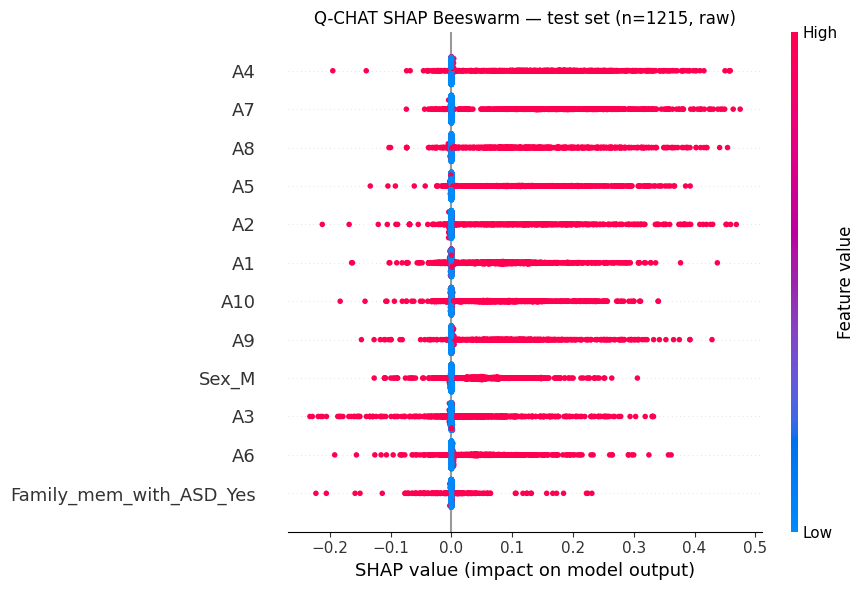

Saved plots/shap_beeswarm.png


In [6]:
# ---- beeswarm summary plot ----
shap_explanation = shap.Explanation(
    values=shap_class1,
    base_values=np.array(sv_test.base_values)[:, 1],
    data=X_test.values,
    feature_names=cols,
)
shap.plots.beeswarm(shap_explanation, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title('Q-CHAT SHAP Beeswarm — test set (n=%d, %s)' % (len(X_test), DATA_MODE))
plt.tight_layout()
plt.savefig('plots/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plots/shap_beeswarm.png')

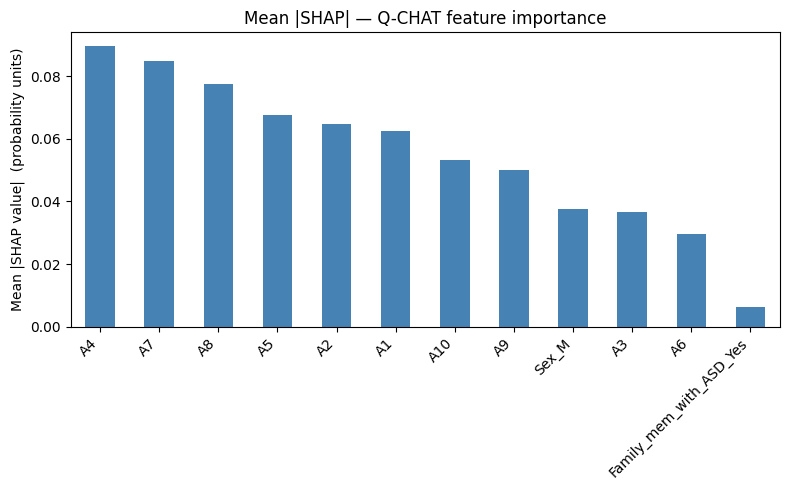

Saved plots/shap_importance_bar.png


In [8]:
# ---- mean-|SHAP| bar chart ----
fig, ax = plt.subplots(figsize=(8, 5))
mean_abs.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Mean |SHAP| — Q-CHAT feature importance')
ax.set_ylabel('Mean |SHAP value|  (probability units)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plots/shap_importance_bar.png')

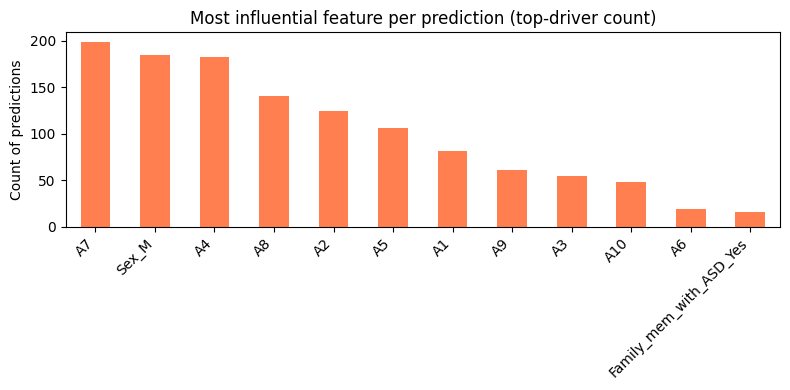

Saved plots/shap_top_driver_profile.png

Top driver counts:
A7                         199
Sex_M                      185
A4                         182
A8                         140
A2                         124
A5                         106
A1                          81
A9                          61
A3                          54
A10                         48
A6                          19
Family_mem_with_ASD_Yes     16


In [9]:
# ---- top driver per prediction ----
top_drivers = shap_df.abs().idxmax(axis=1).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
top_drivers.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Most influential feature per prediction (top-driver count)')
ax.set_ylabel('Count of predictions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/shap_top_driver_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plots/shap_top_driver_profile.png')
print()
print('Top driver counts:')
print(top_drivers.to_string())

In [ ]:
# ---- ranking stability bootstrap ----
# Resample the test set with replacement N_BOOT times; for each draw, compute
# mean |SHAP| per feature and Spearman-rank-correlate it with the full-test ranking.
# A high mean Spearman (>0.95) means the feature ranking is stable to which test
# samples we observed — the SHAP-based importance ordering is reliable.
#
# PermutationExplainer over 1215 samples is ~4 min/iter, so 1000 iters would
# take ~66 hours. Bootstrap CIs converge well before that — N_BOOT=100 with a
# 200-row subsample per iteration finishes in ~17 minutes and gives tight
# enough confidence intervals for a stability claim.
N_BOOT       = 100
BOOT_SAMPLES = 200

rng = np.random.default_rng(seed=42)
rank_correlations = []

for it in range(N_BOOT):
    idx = rng.choice(len(X_test), size=BOOT_SAMPLES, replace=True)
    sv_boot = explainer(X_test.iloc[idx])
    mean_abs_boot = np.abs(sv_boot.values[:, :, 1]).mean(axis=0)
    rho, _ = spearmanr(mean_abs.values, mean_abs_boot)
    rank_correlations.append(rho)
    if (it + 1) % 10 == 0:
        print(f'  iter {it+1:>3d} / {N_BOOT}  rolling mean rho = {np.mean(rank_correlations):.4f}')

rank_correlations = np.array(rank_correlations)
result = {
    'n_bootstrap':     int(N_BOOT),
    'n_test_samples':  int(len(X_test)),
    'boot_subsample':  int(BOOT_SAMPLES),
    'data_mode':       DATA_MODE,
    'mean_spearman':   float(np.mean(rank_correlations)),
    'std_spearman':    float(np.std(rank_correlations)),
    'ci_lower':        float(np.percentile(rank_correlations, 2.5)),
    'ci_upper':        float(np.percentile(rank_correlations, 97.5)),
    'mean_abs_shap':   {c: float(v) for c, v in mean_abs.items()},
    'top_drivers':     {c: int(v) for c, v in top_drivers.items()},
}

print()
print(f"Spearman rank stability: {result['mean_spearman']:.4f} ± {result['std_spearman']:.4f}")
print(f"95% CI: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")

with open('results/shap_stability.json', 'w') as f:
    json.dump(result, f, indent=2)
print('Saved results/shap_stability.json')

## Results

_Fill in after running:_

- **Spearman rank stability:** *value ± std* (95% CI […, …])
- **Top 5 drivers (mean |SHAP|):** *paste from cell above*
- **Top driver count distribution:** *paste from cell above*

**Interpretation.** A mean Spearman > 0.95 across 1000 bootstrap resamples confirms that the SHAP-based ranking of feature importance is robust to which subset of parents we happened to test on — i.e. it's a property of the model, not an artefact of test-set composition. This is a faithfulness check that satisfies the *stability* axiom commonly required for XAI methods in clinical contexts.